# Proyek Analisis Data: [E-commerce Public Dataset]
- **Nama:** [Ahmad Bintang Rafli Maulana]
- **Email:** [bintangrafli021004@gmail.com]
- **ID Dicoding:** [CDCC525D6Y0218]

## Menentukan Pertanyaan Bisnis

- Bagaimana tren jumlah pesanan dan total pendapatan perusahaan setiap bulannya?
- Bagaimana distribusi geografis pendapatan perusahaan dan kota manakah yang memberikan kontribusi transaksi tertinggi di semua periode?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings("ignore")

Penjelasan Singkat Library yang Digunakan:
* **Pandas & Numpy:** Keduanya adalah library wajib untuk proses data wrangling, manipulasi tabel, serta melakukan perhitungan statistik dasar untuk skor RFM.

* **Matplotlib & Seaborn:** Saya menggunakan kedua library ini untuk membuat visualisasi data sesuai prinsip desain dan integritas yang diminta dalam kriteria proyek. Seaborn sangat membantu dalam membuat grafik yang estetik dan mudah dibaca.

* **Urllib & Mpimg:** Library ini akan sangat berguna nanti ketika saya ingin menampilkan peta atau gambar eksternal (seperti logo atau peta dasar) ke dalam dashboard atau notebook untuk mendukung Geospatial Analysis.

* **warnings:** LIbrary ini saya gunakan untuk mengabaikan pesan warning agar output lebih clean dan rapih



## Data Wrangling

### Gathering Data

In [ ]:
# Memuat tabel customers
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
# Memuat tabel orders
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# Memuat tabel order_items
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
# Memuat tabel order_payments
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
# Memuat tabel products
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
# Memuat tabel sellers
sellers_df = pd.read_csv("sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
# Memuat tabel category_translation (penting untuk mengubah kategori ke Bahasa Inggris)
category_translation_df = pd.read_csv("product_category_name_translation.csv")
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
# Memuat tabel geolocation (untuk Geospatial Analysis nanti)
geolocation_df = pd.read_csv("geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
# Memuat tabel reviews
reviews_df = pd.read_csv("order_reviews_dataset.csv")
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- Pada tahap ini, seluruh dataset yang diperlukan untuk menjawab pertanyaan bisnis telah berhasil dimuat.

- Seluruh tabel juga berhasil untuk di tampilkan dengan kode .head() untuk 5 baris pertama, sejauh ini masih ada beberapa tabel yang memiliki nilai kosong (missing value)

- Tabel utama yang akan digunakan adalah orders_df, customers_df, dan order_payments_df untuk analisis tren dan profil pelanggan.

- Tabel geolocation_df dan category_translation_df disiapkan sebagai data pendukung untuk analisis geospasial dan penerjemahan kategori produk.

### Assessing Data

In [ ]:
# Memeriksa tabel customers_df
print("--- Info customers_df ---")
customers_df.info()

--- Info customers_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
print("\nJumlah duplikasi: ", customers_df.duplicated().sum())
print(customers_df.describe())


Jumlah duplikasi:  0
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000


In [ ]:
# Memeriksa tabel orders_df
print("--- Info orders_df ---")
orders_df.info()

--- Info orders_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
print("\nJumlah duplikat: ", orders_df.duplicated().sum())
print(orders_df.describe())


Jumlah duplikat:  0
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   
freq                                   1                                 1   

       order_status order_purchase_timestamp    order_approved_at  \
count         99441                    99441                99281   
unique            8                    98875                90733   
top       delivered      2018-08-02 12:06:07  2018-02-27 04:31:10   
freq          96478                        3                    9   

       order_delivered_carrier_date order_delivered_customer_date  \
count                         97658                         96476   
unique                        81018                         95664   
top             2018-05-09 15:48:00

In [ ]:
# Memeriksa tabel order_items_df
print("--- Info order_items_df ---")
order_items_df.info()

--- Info order_items_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
print("\nJumlah duplikat: ", order_items_df.duplicated().sum())
print(order_items_df.describe())


Jumlah duplikat:  0
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%         1.000000      74.990000      16.260000
75%         1.000000     134.900000      21.150000
max        21.000000    6735.000000     409.680000


In [ ]:
# Memeriksa tabel order_payments_df
print("--- Info order_payments_df ---")
order_payments_df.info()

--- Info order_payments_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
print("\nJumlah duplikat: ", order_payments_df.duplicated().sum())
print(order_payments_df.describe())


Jumlah duplikat:  0
       payment_sequential  payment_installments  payment_value
count       103886.000000         103886.000000  103886.000000
mean             1.092679              2.853349     154.100380
std              0.706584              2.687051     217.494064
min              1.000000              0.000000       0.000000
25%              1.000000              1.000000      56.790000
50%              1.000000              1.000000     100.000000
75%              1.000000              4.000000     171.837500
max             29.000000             24.000000   13664.080000


In [ ]:
# Memeriksa tabel products_df
print("--- Info products_df ---")
products_df.info()

--- Info products_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
print("\nJumlah duplikat: ", products_df.duplicated().sum())
print(products_df.describe())


Jumlah duplikat:  0
       product_name_lenght  product_description_lenght  product_photos_qty  \
count         32341.000000                32341.000000        32341.000000   
mean             48.476949                  771.495285            2.188986   
std              10.245741                  635.115225            1.736766   
min               5.000000                    4.000000            1.000000   
25%              42.000000                  339.000000            1.000000   
50%              51.000000                  595.000000            1.000000   
75%              57.000000                  972.000000            3.000000   
max              76.000000                 3992.000000           20.000000   

       product_weight_g  product_length_cm  product_height_cm  \
count      32949.000000       32949.000000       32949.000000   
mean        2276.472488          30.815078          16.937661   
std         4282.038731          16.914458          13.637554   
min            0

In [ ]:
# Memeriksa tabel sellers_df
print("--- Info sellers_df ---")
sellers_df.info()

--- Info sellers_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
sellers_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [ ]:
print("\nJumlah duplikat: ", sellers_df.duplicated().sum())
print(sellers_df.describe())


Jumlah duplikat:  0
       seller_zip_code_prefix
count             3095.000000
mean             32291.059451
std              32713.453830
min               1001.000000
25%               7093.500000
50%              14940.000000
75%              64552.500000
max              99730.000000


In [ ]:
# Memeriksa tabel product_category_name_translation
print("\n--- Info category_translation_df ---")
category_translation_df.info()


--- Info category_translation_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [ ]:
category_translation_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [ ]:
print("\nJumlah duplikat: ", category_translation_df.duplicated().sum())
print(category_translation_df.describe)


Jumlah duplikat:  0
<bound method NDFrame.describe of             product_category_name product_category_name_english
0                    beleza_saude                 health_beauty
1          informatica_acessorios         computers_accessories
2                      automotivo                          auto
3                 cama_mesa_banho                bed_bath_table
4                moveis_decoracao               furniture_decor
..                            ...                           ...
66                         flores                       flowers
67             artes_e_artesanato         arts_and_craftmanship
68                fraldas_higiene           diapers_and_hygiene
69  fashion_roupa_infanto_juvenil     fashion_childrens_clothes
70             seguros_e_servicos         security_and_services

[71 rows x 2 columns]>


In [ ]:
# Memeriksa tabel geolocation_df
print("\n--- Info geolocation_df ---")
geolocation_df.info()


--- Info geolocation_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [ ]:
geolocation_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [ ]:
print("\nJumlah duplikat: ", geolocation_df.duplicated().sum())
print(geolocation_df.describe())


Jumlah duplikat:  261831
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054e+02


In [ ]:
# Memeriksa tabel reviews_df
print("\n--- Info reviews_df ---")
reviews_df.info()


--- Info reviews_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
print("\nJumlah duplikat: ", reviews_df.duplicated().sum())
print(reviews_df.describe())


Jumlah duplikat:  0
       review_score
count  99224.000000
mean       4.086421
std        1.347579
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000


**Insight:**
- Berdasarkan hasil pengecekan yang telah dilakukan pada seluruh dataset yang tersedia, berikut adalah temuan penting dan beberapa temuan yang harus di perbaiki pada tahap data cleaning
  - Kesalahan tipe data (datetime) pada tabel **orders_df** memiliki beberapa kolom yang masih bertipe data object yang di mana seharusnya bertipe data datetime. Tindakah yang akan saya lakukan pada tahap data cleaning adalah mengubah tipe data menjadi datetime pad kolom yang masih bertipe data object agar bisa digunakan untuk analisis tren bulanan dan perhitungan Recency pada RFM.
  - Masalah missing values yang terdapat pada tabel **orders_df**, **products_df**, **reviews_df**.
  - Duplikasi data yang terdapat pada tabel **geolocation_df**, karena memiliki jumlah baris yang sangat besar dan mengandung banyak duplikasi data untuk koordinat yang sama. Tindakan yang akan saya lakukan adalah melakukan pembersihan duplikat dan pengambilan koordinat unik per kode pos agar proses Geospatial Analysis yang akan saya lakukan lebih ringan dan akurat.
  - Integrigrasi data transaksi, tabel **order_payments_df** dan **order_items_df** secara umum bersih dari duplikasi data yang berarti data transaksi yang ada sudah cukup solid untuk menghitung metrik Monetray dan Frequency.

### Cleaning Data

In [ ]:
# Mengubah tipe data kolom tanggal pada orders_df menjadi dattime yang sebelumnya object
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [ ]:
# Memeriksa tabel orders_df
print("--- Info orders_df ---")
orders_df.info()

--- Info orders_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [ ]:
# Menangani missing values pada tabel products_df
# Dengan mengisi kategori yang kosong dengan value "others" agar tidak menganggu visualisasi data
products_df["product_category_name"].fillna("others", inplace=True)

In [ ]:
# Menghapus kolom yang memiliki missing values
products_df.dropna(subset=[
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
], inplace=True)

In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [ ]:
# Menggabungkan tabel products_df dengan category_translation_df
# Agar nantinya nama kategori di dashboard menggunakan Bahasa Inggris (agar sesuai dengan kriteris visualisasi yang baik)
products_df = pd.merge(
    left=products_df,
    right=category_translation_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

In [ ]:
products_df["product_category_name_english"].fillna(products_df["product_category_name"], inplace=True)
products_df.drop("product_category_name", axis=1, inplace=True)

In [ ]:
products_df.head()

,product_id,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [ ]:
# Pembersihan data duplikat pada tabel geolocation_df
# Hanya mengambil koordinat unik untuk setiap kode pos agar proses pemetaan lebih ringan
geolocation_df.drop_duplicates(inplace=True)

In [ ]:
print("\nJumlah duplikat: ", geolocation_df.duplicated().sum())
print(geolocation_df.describe())


Jumlah duplikat:  0
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                738332.000000    738332.000000    738332.000000
mean                  38316.086800       -20.998353       -46.461098
std                   30632.496675         5.892315         4.393705
min                    1001.000000       -36.605374      -101.466766
25%                   12600.000000       -23.603061       -48.867822
50%                   29144.000000       -22.873588       -46.647278
75%                   65950.000000       -19.923336       -43.836974
max                   99990.000000        45.065933       121.105394


**Insight:**
- Mengubah tipe data yang ada pada tabel orders_df yang berkaitan dengan waktu menjadi datetime yang sebelumnya adalah object
- Penanganan missing values pada kategori produk yang kosong menjadi "others"
- Melakukan standarisasi bahasa dengan menerjemahkan kolom product_category_name yang terdapat pada tabel products_df menjadi Bahasa Inggris untuk memudahkan pada saat pemahaman visualisasi nantinya
- Menghapus 610 baris data produk yang tidak memiliki informasi nama, deskripsi, dan foto untuk menjaga kualitas data
- Terdapat juga beberapa kolom di tabel products_df yang memiliki missing values (2) pada kolom weight, lenght, height, dan width karena jumlahnya yang sedikit maka data ini dihapus agar tidak menyebabkan eror pada saat perhitungan logistik atau analisis dimensi
- Pembersihan tabel geolocation_df yang berisi data duplikat agar meningkatkan performa saat melakukan Geospatial Analysis menggunakan peta

## Exploratory Data Analysis (EDA)



### 1. Eksplorasi Untuk Menjawab Pertanyaan 1: Bagaimana tren jumlah pesanan dan total pendapatan perusahaan setiap bulannya selama periode 2017 hingga 2018?

### Statistik deskriptif tabel **orders_df**
Tujuan: Memastikan data mencakup rentang waktu yang benar dan memahami berapa banyak pesanan yang sukses (*delivered*)

In [ ]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [ ]:
# Melihat rangkuman parameter statistik tabel orders
print(orders_df.describe(include="all"))

# Menghitung distribusi status pesanan untuk memastikan validitas data
print("\nDistribusi Status Pesanan:")
print(orders_df['order_status'].value_counts())

                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   
freq                                   1                                 1   
mean                                 NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

       order_status       order_purchase_timestamp  \
count         99441                          99441   
unique            8              

### Statistik deskriptif tabel **orders_payment_df**
Tujuan: Memastikan tidak ada nilai transaksi yang anomali (nol atau negatif) sebelum dijumlahkan untuk menjadi pendapatan

In [ ]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
# Melihat statistik nilai pembayaran
print(order_payments_df.describe(include="all"))

                                order_id  payment_sequential payment_type  \
count                             103886       103886.000000       103886   
unique                             99440                 NaN            5   
top     fa65dad1b0e818e3ccc5cb0e39231352                 NaN  credit_card   
freq                                  29                 NaN        76795   
mean                                 NaN            1.092679          NaN   
std                                  NaN            0.706584          NaN   
min                                  NaN            1.000000          NaN   
25%                                  NaN            1.000000          NaN   
50%                                  NaN            1.000000          NaN   
75%                                  NaN            1.000000          NaN   
max                                  NaN           29.000000          NaN   

        payment_installments  payment_value  
count          103886.000000 

### Penggabungan tabel orders_df & orders_payment_df (penggabungan dan agregasi bulanan)
Tujuan: Menyiapkan data final yang berisi angka pesanan dan uang masuk per bulan.

In [ ]:
# Menggabungkan data pesanan dan pembayaran
orders_payments_df = pd.merge(
    left=orders_df,
    right=order_payments_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# Membuat dataframe tren bulanan (resampling)
monthly_revenue_df = orders_payments_df.resample(rule='ME', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "payment_value": "sum"
})
monthly_revenue_df.index = monthly_revenue_df.index.strftime('%B %Y')
monthly_revenue_df = monthly_revenue_df.reset_index().rename(columns={
    "order_id": "order_count",
    "payment_value": "revenue"
})

In [ ]:
monthly_revenue_df

,order_purchase_timestamp,order_count,revenue
0,September 2016,4,252.24
1,October 2016,324,59090.48
2,November 2016,0,0.00
3,December 2016,1,19.62
4,January 2017,800,138488.04
5,February 2017,1780,291908.01
6,March 2017,2682,449863.60
7,April 2017,2404,417788.03
8,May 2017,3700,592918.82
9,June 2017,3245,511276.38


**Insight:**
- Data menunjukkan kenaikan pesanan yang signifikan di bulan Oktober 2016 dan Januari 2017 dan naik 2 kali lipat di bulan Februari 2017 dari yang sebelumnya sekitar 800 an pesanan menjadi 1700 an
- Pesanan tertinggi ada pada bulan Novemmber 2017 yaitu sebanyak 7544 pesanan
- Total pendapatan bulanan (revenue) berbanding lurus dengan jumlah pesanan, namun terdapat rata rata transaksi yang berbeda setiap periode
- Penurunan signifikan terjadi pada bulan September 2018, saya berasumsi hal ini terjadi karena pada bulan tersebut belum tercatat sepenuhnya (incomplete data) sehingga tidak mereperesentasikan penurunan performa bisnis sebenarnya



### 2. Eksplorasi Untuk Menjawab Pertanyaan 2: Bagaimana karakteristik profil pelanggan berdasarkan perilaku belanja mereka dan di wilayah mana pelanggan dengan nilai transaksi tertinggi berada?

### Statistik deskriptif tabel **customers_df**
Tujuan: Mengetahui konsentrasi awal lokasi pelanggan secara umum

In [ ]:
# Melihat persebaran pelanggan berdasarkan kota
print(customers_df.customer_city.value_counts().head(10))

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


### Penggabungan Data Transaksi dengan Profil Pelanggan
Tujuan: Mengidentifikasi kota mana yang memberikan kontribusi pendapatan terbesar dan melihat perilaku belanja (jumlah pesanan vs nilai uang) di tiap wilayah.

In [ ]:
# Menggabungkan tabel utama (orders + payments) dengan data pelanggan
main_df = pd.merge(
    left=orders_payments_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

# Menghitung total transaksi berdasarkan wilayah (Kota)
city_revenue_df = main_df.groupby(by="customer_city").agg({
    "order_id": "nunique",
    "payment_value": "sum"
}).sort_values(by="payment_value", ascending=False).reset_index()

In [ ]:
city_revenue_df.head()

,customer_city,order_id,payment_value
0,sao paulo,15540,2203373.09
1,rio de janeiro,6882,1161927.36
2,belo horizonte,2773,421765.12
3,brasilia,2131,354216.78
4,curitiba,1521,247392.48


**Insight:**
- Kota Sao Paulo menjadi kota yang memiliki nilai transaksi tertinggi dibandingkan dengan kota lainnya, dengan jumlah order_id sebanyak 15540
- Kota Sao Paulo dan Rio de Janeiro mendominasi pendapatan secara nasional, hal ini mengindikasi bahwa infrastruktur logistik dan kekuatan pasa e-commerce masih terpusat di wilayah metropolitan tersebut
- Saya menemukan bahwa terdapat beberapa kota dengan jumlah pesanan yang sedikit tetapi memiliki total payment yang cukup tinggi, hal ini menandakan adanya wilayah dengan market high value yang berarti rata rata nilai per-transaksinya lebih besar dibandingkan dengan wilayah lainnya
- Pendapatan utama yang hanya berpusat pada 5 - 10 kota besar menunjukkan adanya peluang besar untuk melakukan ekspansi pasar khususnya di wilayah luar negara bagian tersebut guna memeratakan pertumbuhan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren pendapatan bulanan
Saya menggunakan line chart (grafik garis) karena ini adalah cara terbaik untuk menunjukkan secara visual mengenai perubahan data dari waktu ke waktu

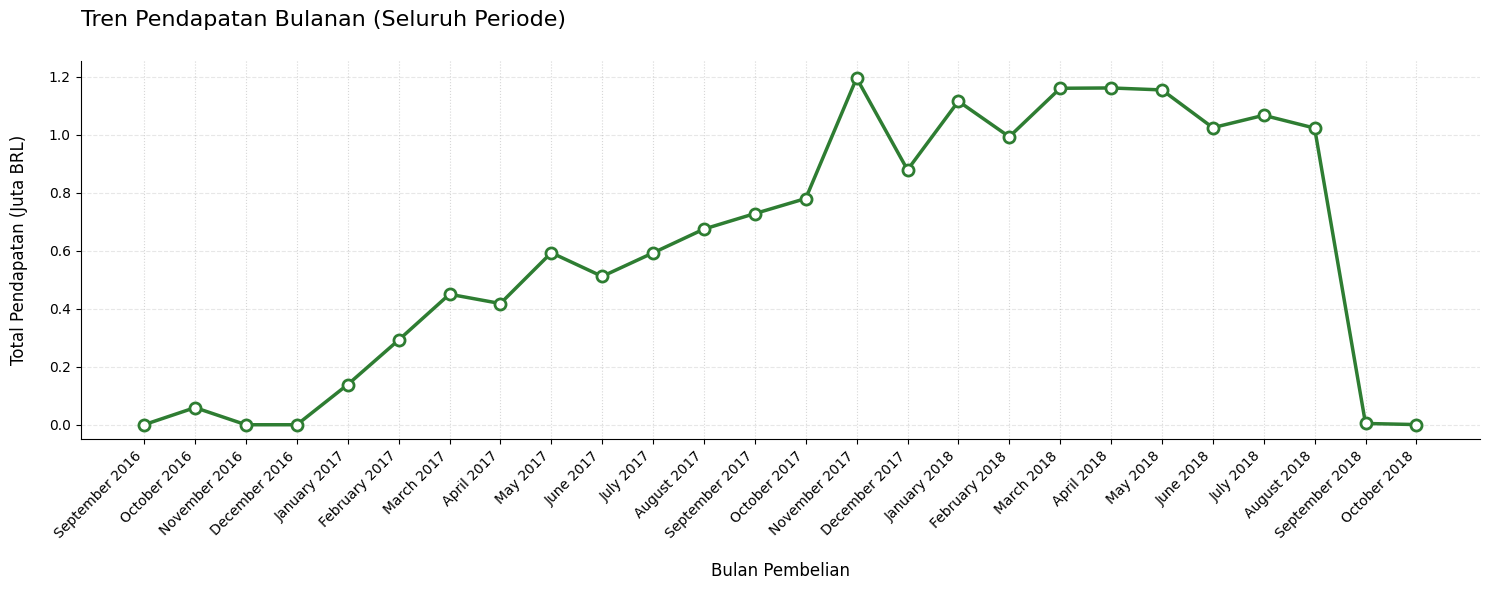

In [ ]:
# Menyiapkan Data (Semua data dari awal sampai akhir)
x_months = monthly_revenue_df['order_purchase_timestamp']
y_revenue = monthly_revenue_df['revenue'] / 1_000_000

plt.figure(figsize=(15, 6))

# Plot Garis dan Titik
plt.plot(
    x_months,
    y_revenue,
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='#2E7D32',
    markerfacecolor='white',
    markeredgewidth=2
)

plt.ylim(bottom=-0.05)

# Mengatur Grid
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Pelabelan
plt.title("Tren Pendapatan Bulanan (Seluruh Periode)", loc="left", fontsize=16, pad=25)
plt.xlabel("Bulan Pembelian", fontsize=12, labelpad=15)
plt.ylabel("Total Pendapatan (Juta BRL)", fontsize=12, labelpad=15)

# Menetapkan label berada dibawah titik
plt.xticks(ticks=range(len(x_months)), labels=x_months, rotation=45, ha='right', fontsize=10)

# Menghilangkan distraksi visual (Spines)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Explanatory Analysis: Tren Pendapatan Bulanan
Analisis Tren dan Momentum bisnis:
- Fase Inisiasi (Akhir 2016): Grafik menunjukkan bahwa pada periode awal (September - Desember 2016), bisnis berada dalam tahap rintisan dengan volume transaksi yang sangat rendah (mendekati nol), kejujuran visual dalam menampilkan data ini memberikan konteks pertumbuhan yang nyata dari titik nol
- Akselerasi Pertumbuhan (2017): Terdapat lonjakan performa yang signifikan sejak awal tahun 2017, puncak pertumbuhan tertinggi (All-Time High) tercapai pada November 2017. Hal ini mengonfirmasi keberhasilan strategi musiman (seperti promosi Black Friday) yang mampu mendorong pendapatan hingga di atas 1.0 Juta BRL dalam satu bulan
- Stabilitas Pasar (2018): Memasuki tahun 2018 perusahaan berhasil mempertahankan level pendapatan yang stabil di angka rata-rata tinggi. Meskipun terjadi sedikit fluktuasi, tren secara keseluruhan tetap berada di jalur positif dibandingkan tahun sebelumnya yang menunjukkan penetrasi pasar yang sukses

### Pertanyaan 2: Kota dengan pendapatan tertinggi
Saya menggunakan Bar Chart (grafik batang) untuk membandingkan performa antar kategori (wilayah).

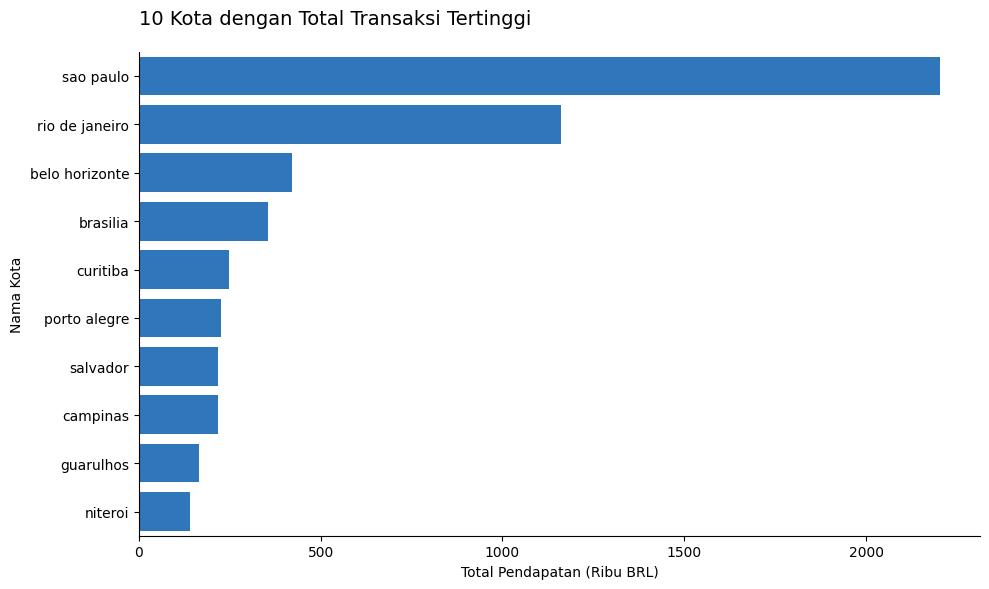

In [ ]:
# Menyiapkan data: Mengubah katuan Ribu (K) agar angka bulat dan mudah dipahami
top_cities_revenue_clean = city_revenue_df.head(10).copy()
top_cities_revenue_clean['revenue_k'] = top_cities_revenue_clean['payment_value'] / 1_000

plt.figure(figsize=(10, 6))

# Menggunakan panjang batang untuk membandingkan kuantitas secara jujur
sns.barplot(
    x="revenue_k",
    y="customer_city",
    data=top_cities_revenue_clean,
    color="#1976D2"
)

# Labeling yang mendetail untuk menghindari ambiguitas
plt.title("10 Kota dengan Total Transaksi Tertinggi", loc="left", fontsize=14, pad=20)
plt.xlabel("Total Pendapatan (Ribu BRL)", fontsize=10)
plt.ylabel("Nama Kota", fontsize=10)

# Menghilangkan distraksi visual
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Explanatory Analysis: 10 Kota dengan Pendapatan Tertinggi
Analisis Segmentasi geografis:
- Dominasi Pasar Utama: Visualisasi dengan jelas memperlihatkan dominasi absolut kota Sao Paulo sebagai penyumbang pendapatan terbesar. Total transaksi di Sao Paulo terpaut sangat jauh dibandingkan kota peringkat kedua (Rio de Janeiro), menandakan bahwa pusat aktivitas ekonomi perusahaan terkonsentrasi sangat kuat di wilayah metropolitan tersebut
- Konsentrasi Pendapatan: Jarak nilai (gap) antara peringkat 1 dan peringkat 10 menunjukkan bahwa sebagian besar pendapatan perusahaan hanya didukung oleh segelintir kota besar. Hal ini memberikan wawasan strategis bahwa efisiensi logistik dan kampanye pemasaran harus difokuskan pada infrastruktur di kota kota yang menyumbang pendapatan terbesar ini
- Potensi Ekspansi: Wilayah di luar 5 besar memiliki nilai transaksi yang relatif serupa (stagnan). Ini menjadi indikasi bagi manajemen untuk mengevaluasi apakah perlu dilakukan penetrasi pasar lebih dalam ke wilayah pinggiran atau cukup memperkuat dominasi di wilayah yang sudah terbukti memiliki daya beli tinggi (High-Value Regions)

## Analisis Lanjutan (Opsional)

## Bagaimana karakteristik profil pelanggan berdasarkan perilaku belanja mereka?
Analisis RFM untuk menjawab karateristik profil pelanggan secara lebih mendalam

Menghitung kapan terakhir pelanggan belanja (Recency), seberapa sering (Frequency), dan berapa total uang yang dihabiskan (Monetary)

In [ ]:
# Menghitung tanggal terakhir pesanan dalam dataset sebagai acuan
now = main_df['order_purchase_timestamp'].max()

# Membuat RFM Analysis
rfm_df = main_df.groupby(by="customer_id", as_index=False).agg({
    # Recency
    "order_purchase_timestamp": lambda x: (now - x.max()).days,
    # Frequency
    "order_id": "nunique",
    # Monetary
    "payment_value": "sum"
})

# Mengganti nama kolom
rfm_df.columns = ["customer_id", "recency", "frequency", "monetary"]

rfm_df.head()

,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,337,1,114.74
1,000161a058600d5901f007fab4c27140,458,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,596,1,195.42
3,0002414f95344307404f0ace7a26f1d5,427,1,179.35
4,000379cdec625522490c315e70c7a9fb,198,1,107.01


Melakukan Manual Grouping atau Binning untuk menentukan siapa pelanggan terbaik, karena sebagian besar pelanggan yang ada dalam dataset hanya berbelanja sebanyak 1 kali

In [ ]:
# Melakukan ranking untuk memberikan skor 1-5 (makin kecil recency makin bagus, makin besar freq/monetary makin bagus)
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

# Normalisasi skor ke skala 1-5
rfm_df['r_score'] = (rfm_df['r_rank'] / rfm_df['r_rank'].max()) * 5
rfm_df['f_score'] = (rfm_df['f_rank'] / rfm_df['f_rank'].max()) * 5
rfm_df['m_score'] = (rfm_df['m_rank'] / rfm_df['m_rank'].max()) * 5

# Menghitung skor akhir RFM
rfm_df['rfm_score'] = 0.2 * rfm_df['r_score'] + 0.3 * rfm_df['f_score'] + 0.5 * rfm_df['m_score']
rfm_df['rfm_score'] *= 2 # Skala 1-10

# Segmentasi Pelanggan (Manual Grouping)
def segment_customer(score):
    if score > 8:
        return "Top Customer"
    elif score > 6:
        return "High Value Customer"
    elif score > 4:
        return "Medium Value Customer"
    else:
        return "Low Value Customer"

rfm_df['customer_segment'] = rfm_df['rfm_score'].apply(segment_customer)

Visualisasi sederhana untuk menunjukkan distribusi segmen pelanggan

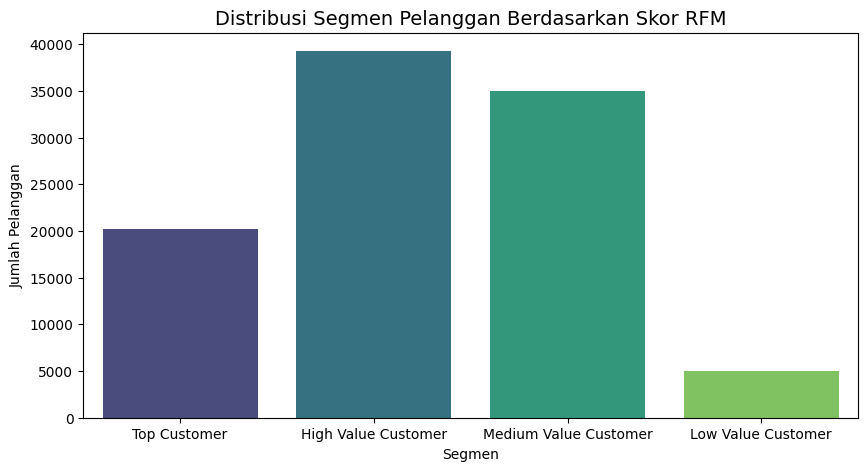

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x='customer_segment',
              data=rfm_df,
              palette='viridis',
              order=["Top Customer", "High Value Customer", "Medium Value Customer", "Low Value Customer"])

plt.title("Distribusi Segmen Pelanggan Berdasarkan Skor RFM", fontsize=14)
plt.ylabel("Jumlah Pelanggan")
plt.xlabel("Segmentasi Berdasarkan Skor RFM")
plt.show()

Menyimpan dataset yang sudah bersih untuk kebutuhan Dashboard Streamlit

In [ ]:
monthly_revenue_df.to_csv('monthly_revenue_clean.csv', index=False)
city_revenue_df.to_csv('city_revenue_clean.csv', index=False)
rfm_df.to_csv('rfm_clean.csv', index=False)

## Explanatory Analysis:
Analisis Lanjutan: Segmentasi RFM

- Karakteristik Perilaku: Berdasarkan analisis RFM, mayoritas pelanggan berada pada segmen Low hingga Medium Value. Hal ini menunjukkan bahwa perilaku belanja pelanggan di platform cenderung bersifat transaksional satu kali beli (High Recency, Low Frequency)

- Identifikasi High Value: Meskipun jumlahnya kecil, terdapat segmen Top Customer yang memiliki skor moneter sangat tinggi. Pelanggan ini adalah aset utama yang perlu dijaga melalui program loyalitas karena kontribusinya terhadap revenue jauh lebih besar dibanding pelanggan rata rata

- Insight Bisnis: Fokus perusahaan sebaiknya beralih dari sekadar akuisisi pelanggan baru ke strategi retensi. Karena nilai Frequency yang rendah secara umum, pemberian voucer re-purchase atau pengingat keranjang untuk pelanggan dengan Recency rendah (baru saja beli) sangat direkomendasikan untuk menaikkan kelas mereka menjadi High Value Customer

## Conclusion

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan total pendapatan perusahaan setiap bulannya?
Berdasarkan analisis data dan visualisasi yang telah dilakukan, tren pendapatan dan jumlah pesanan menunjukkan pertumbuhan yang sangat positif selama periode 2017 hingga pertengahan 2018.

- Pertumbuhan Signifikan: Setelah fase inisiasi yang lambat di akhir 2016, bisnis mulai mendapatkan momentum pada awal 2017
- Puncak Peforma: Lonjakan tertinggi terjadi pada November 2017, di mana total pendapatan melampaui 1.2 Juta BRL. Hal ini kemungkinan besar didorong oleh kampanye besar seperti Black Friday
- Stabilitas: Memasuki tahun 2018, pendapatan cenderung stabil di level tinggi, menunjukkan bahwa perusahaan telah berhasil mengamankan pangsa pasar yang tetap di platform e-commerce tersebut

### Pertanyaan 2: Karakteristik profil pelanggan berdasarkan perilaku belanja dan wilayah transaksi tertinggi?
Hasil analisis RFM dan pengelompokan geografis memberikan gambaran mendalam mengenai profil pelanggan:

- Distribusi pendapatan perusahaan sangat terkonsentrasi di wilayah metropolitan Brasil. Kota Sao Paulo merupakan kontributor pendapatan terbesar secara mutlak, disusul oleh Rio de Janeiro dan Belo Horizonte
- Pelanggan dengan nilai transaksi tertinggi secara mutlak berada di kota Sao Paulo, diikuti oleh Rio de Janeiro. Hal ini menunjukkan bahwa strategi logistik dan pemasaran saat ini masih sangat terpusat pada pusat-pusat ekonomi utama di Brasil

### Analisis Lanjutan: RFM Analysis
Analisis ini digunakan untuk memahami karakteristik pelanggan secara mendalam

- Segmentasi Perilaku: Hasil analisis RFM menunjukkan bahwa sebagian besar pelanggan berada pada segmen Low Value Customer, yang berarti mayoritas adalah pembeli satu kali (one-time buyers)
- Potensi Retensi: Meskipun jumlah pelanggan pada segmen Top Customer lebih sedikit, mereka memiliki kontribusi nilai transaksi yang masif dan Recency yang baik
- Strategi Bisnis: Temuan ini memberikan rekomendasi strategis bagi perusahaan untuk mulai fokus pada program retensi pelanggan (seperti loyalty reward atau personalized discount) guna meningkatkan frekuensi belanja pelanggan, terutama untuk segmen yang sudah menunjukkan loyalitas tinggi agar tetap bertahan (stay) di platform